In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, norm, poisson


SciPy импортирован успешно


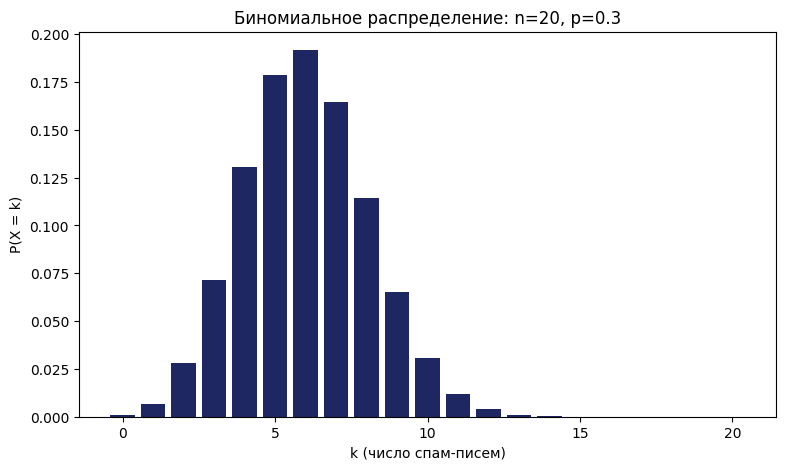

E[X]: scipy=6.0000, по формуле=6.0000
D[X]: scipy=4.2000, по формуле=4.2000
P(X=5) = 0.1789


In [2]:
n, p = 20, 0.3
k_values = np.arange(0, n + 1)
 
pmf_values = binom.pmf(k_values, n, p)     # используйте метод для PMF
 
plt.figure(figsize=(9, 5))
plt.bar(k_values, pmf_values, color='#1E2761')
plt.xlabel('k (число спам-писем)')
plt.ylabel('P(X = k)')
plt.title(f'Биномиальное распределение: n={n}, p={p}')
plt.show()
 
mean_scipy = binom.mean(n, p)     # метод для математического ожидания
var_scipy  = binom.var(n, p)     # метод для дисперсии
mean_formula = n * p
var_formula  = n * p * (1 - p)
 
print(f"E[X]: scipy={mean_scipy:.4f}, по формуле={mean_formula:.4f}")
print(f"D[X]: scipy={var_scipy:.4f}, по формуле={var_formula:.4f}")
print(f"P(X=5) = {pmf_values[5]:.4f}")


Совпадают ли значения, вычисленные scipy, с формулами из лекции? Почему в данном случае совпадение должно быть точным (в отличие от эмпирических оценок из Практики 1)?

Совпадают, ведь здесь нет случайных значений

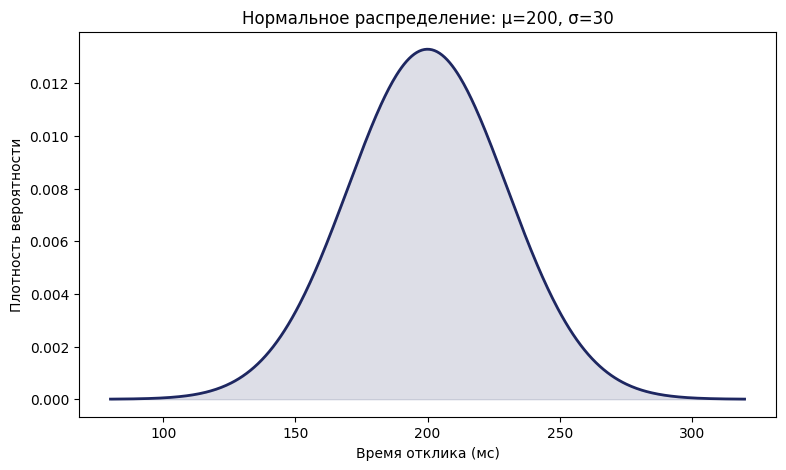

P(X > 260) = 0.0228
P(|Z| < 1) = 0.6827
P(|Z| < 2) = 0.9545
P(|Z| < 3) = 0.9973


In [3]:
mu, sigma = 200, 30
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
pdf_values = norm.pdf(x, mu, sigma)     # используйте метод для PDF

plt.figure(figsize=(9, 5))
plt.plot(x, pdf_values, color='#1E2761', linewidth=2)
plt.fill_between(x, pdf_values, alpha=0.15, color='#1E2761')
plt.xlabel('Время отклика (мс)')
plt.ylabel('Плотность вероятности')
plt.title(f'Нормальное распределение: μ={mu}, σ={sigma}')
plt.show()
 
# Вероятность того, что время отклика превысит 260 мс
p_greater_260 = 1 - norm.cdf(260, mu, sigma)   # используйте метод для CDF
print(f"P(X > 260) = {p_greater_260:.4f}")
 
# Проверка правила трёх сигм для стандартного нормального распределения
for k in [1, 2, 3]:
    p_within = norm.cdf(k) - norm.cdf(-k)
    print(f"P(|Z| < {k}) = {p_within:.4f}")


Совпадает ли P(X>260), вычисленная через norm.cdf(), со значением ≈0,0228, которое мы получили на лекции вручную через таблицу «трёх сигм»? Если есть небольшое отличие — с чем оно связано?

Совпадает идеально

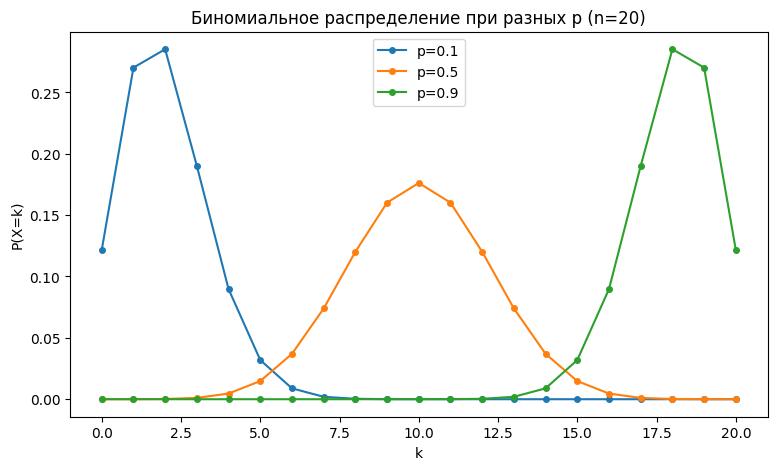

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
 
n = 20
k_values = np.arange(0, n + 1)
 
plt.figure(figsize=(9, 5))
for p in [0.1, 0.5, 0.9]:
    pmf_values = binom.pmf(k_values, n, p)     # подставьте текущее p
    plt.plot(k_values, pmf_values, marker='o', markersize=4, label=f'p={p}')
 
plt.xlabel('k')
plt.ylabel('P(X=k)')
plt.title('Биномиальное распределение при разных p (n=20)')
plt.legend()
plt.show()


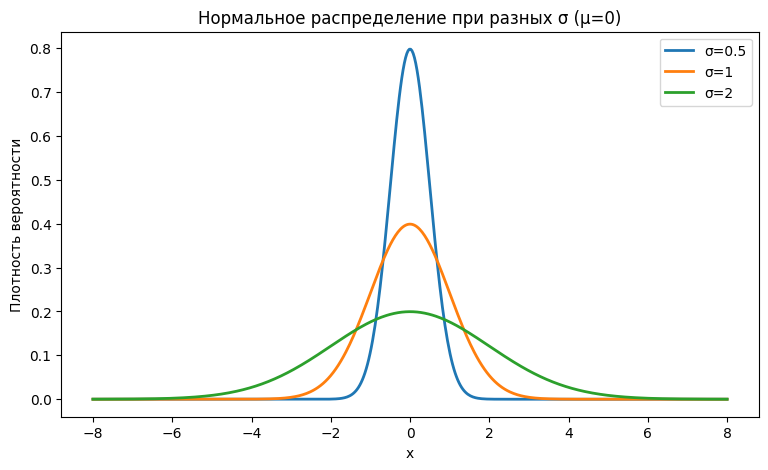

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
 
x = np.linspace(-8, 8, 500)
 
plt.figure(figsize=(9, 5))
for sigma in [0.5, 1, 2]:
    pdf_values = norm.pdf(x, 0, sigma)     # подставьте текущее sigma
    plt.plot(x, pdf_values, linewidth=2, label=f'σ={sigma}')

plt.xlabel('x')
plt.ylabel('Плотность вероятности')
plt.title('Нормальное распределение при разных σ (μ=0)')
plt.legend()
plt.show()


Какая кривая биномиального распределения выглядит наиболее симметричной? Согласуется ли это с тем, что говорилось на лекции? Как меняется высота пика нормального распределения при увеличении σ и почему (вспомните: площадь под кривой всегда равна 1)?

Наиболее симметрично выглядит функция нормального распределения. Высота пика тем выше, чем ниже значение `sigma`.

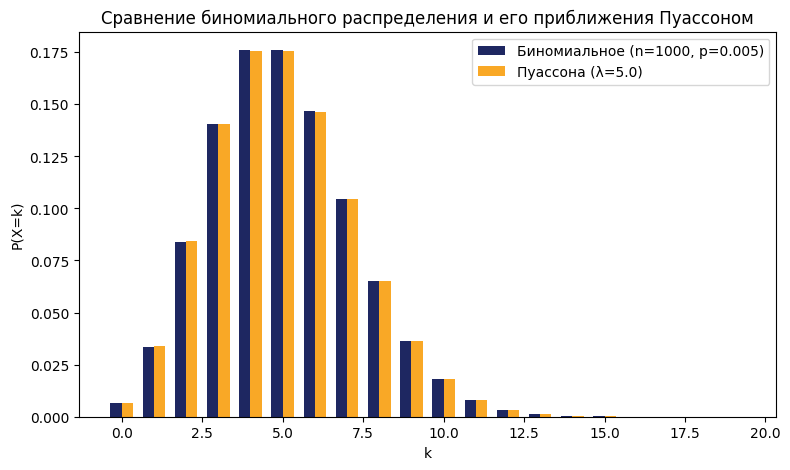

Максимальное отличие вероятностей: 0.000440


In [9]:
n, p = 1000, 0.005
lam = n * p                     # вычислите лямбда = n * p
 
k_values = np.arange(0, 20)
binom_pmf = binom.pmf(k_values, n, p)
poisson_pmf = poisson.pmf(k_values, n * p)    # используйте lam
 
plt.figure(figsize=(9, 5))
width = 0.35
plt.bar(k_values - width/2, binom_pmf, width, label='Биномиальное (n=1000, p=0.005)', color='#1E2761')
plt.bar(k_values + width/2, poisson_pmf, width, label=f'Пуассона (λ={lam})', color='#F9A826')
plt.xlabel('k')
plt.ylabel('P(X=k)')
plt.title('Сравнение биномиального распределения и его приближения Пуассоном')
plt.legend()
plt.show()
 
max_diff = np.max(np.abs(binom_pmf - poisson_pmf))
print(f"Максимальное отличие вероятностей: {max_diff:.6f}")


Насколько малó максимальное отличие между биномиальным и пуассоновским распределениями в этом примере? Как вы думаете, что произойдёт с этим отличием, если взять n=10000, p=0,0005 (при том же λ=5)?

Максимальное отличие измеряется в десятитысячных величинах. Если взять предложенные значения при том же λ, то максимальное отличие станет ещё меньше

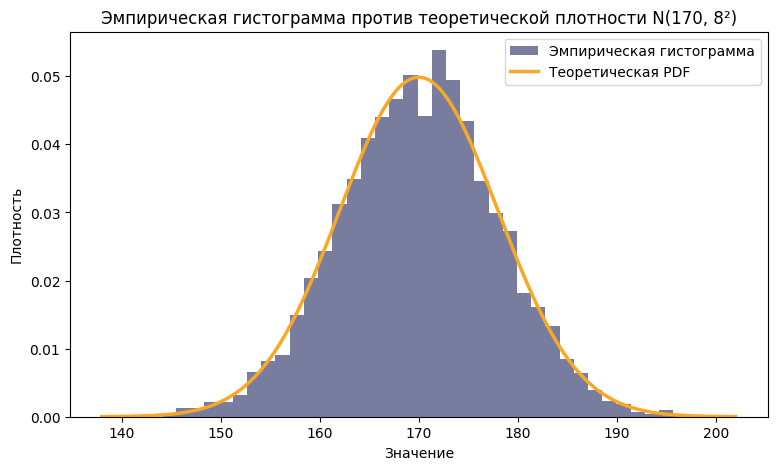

In [11]:
np.random.seed(42)
mu, sigma = 170, 8    # например, рост в см
sample = np.random.normal(mu, sigma, size=5000)
 
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
theoretical_pdf = norm.pdf(x, mu, sigma)
 
plt.figure(figsize=(9, 5))
plt.hist(sample, bins=40, density=True, alpha=0.6, color='#1E2761', label='Эмпирическая гистограмма')
plt.plot(x, theoretical_pdf, color='#F9A826', linewidth=2.5, label='Теоретическая PDF')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.title('Эмпирическая гистограмма против теоретической плотности N(170, 8²)')
plt.legend()
plt.show()
